# 05 — ML Clustering: SME AI Readiness Profiles

**Goal:** Use unsupervised learning to segment US SMEs into distinct AI readiness profiles, revealing natural groupings that can inform targeted policy and vendor strategies.

**Algorithm:** K-Means (primary) + DBSCAN (comparison)

**Expected clusters:**
- Cluster 0 — AI Pioneers
- Cluster 1 — Digital Explorers
- Cluster 2 — Traditional SMEs
- Cluster 3 — Cost-Conscious Adopters

---

## 1. Load Data & Select Clustering Features

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sys
print(sys.executable)
# Debe mostrar: /opt/anaconda3/bin/python3


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Cluster color palette
CLUSTER_COLORS = ['#6B7C3A', '#C47A28', '#2874A6', '#8B5E8B']
CLUSTER_NAMES  = [
    'AI Pioneers',
    'Digital Explorers',
    'Traditional SMEs',
    'Cost-Conscious Adopters'
]

print('Libraries loaded.')

/opt/anaconda3/bin/python
Libraries loaded.


In [2]:
# Load dataset
CLEAN_PATH = '../data/processed/sme_clean.csv'
RAW_PATH   = '../data/raw/sme_ai_adoption_main.csv'

if os.path.exists(CLEAN_PATH):
    df = pd.read_csv(CLEAN_PATH)
    print(f'Loaded CLEAN dataset: {df.shape}')
else:
    df = pd.read_csv(RAW_PATH)
    print(f'Loaded RAW dataset: {df.shape}')

# Clustering features
CLUSTER_FEATURES = [
    'employees', 'revenue_m_usd', 'tech_invest_pct', 'tech_emp_pct',
    'digital_maturity', 'cloud_adopted', 'has_data_strategy',
    'ai_tools_count', 'years_in_business', 'ceo_tech_background'
]

df_cluster = df[CLUSTER_FEATURES + ['ai_adopted', 'industry', 'state', 'size_category']].dropna().copy()
X_raw = df_cluster[CLUSTER_FEATURES].copy()

print(f'Clustering dataset shape: {df_cluster.shape}')
print(f'Features: {CLUSTER_FEATURES}')
X_raw.describe().round(2)

Loaded CLEAN dataset: (5000, 34)
Clustering dataset shape: (5000, 14)
Features: ['employees', 'revenue_m_usd', 'tech_invest_pct', 'tech_emp_pct', 'digital_maturity', 'cloud_adopted', 'has_data_strategy', 'ai_tools_count', 'years_in_business', 'ceo_tech_background']


,employees,revenue_m_usd,tech_invest_pct,tech_emp_pct,digital_maturity,cloud_adopted,has_data_strategy,ai_tools_count,years_in_business,ceo_tech_background
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,36.62,1.66,0.04,0.11,4.59,0.54,0.39,1.74,26.93,0.24
std,41.27,2.07,0.02,0.06,1.92,0.50,0.49,2.39,14.74,0.42
min,1.00,0.05,0.00,0.00,1.00,0.00,0.00,0.00,2.00,0.00
25%,5.00,0.17,0.03,0.07,3.22,0.00,0.00,0.00,14.00,0.00
50%,16.00,0.57,0.04,0.10,4.42,1.00,0.00,0.00,27.00,0.00
75%,48.00,2.49,0.05,0.14,5.81,1.00,1.00,4.00,40.00,0.00
max,112.00,5.97,0.14,0.41,10.00,1.00,1.00,7.00,54.00,1.00


## 2. Scale Features (StandardScaler)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'Scaled array shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean(axis=0).round(4)}')
print(f'Std  (should be ~1): {X_scaled.std(axis=0).round(4)}')

Scaled array shape: (5000, 10)
Mean (should be ~0): [-0.  0.  0.  0.  0. -0.  0.  0. -0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 3. PCA — Reduce to 2 Components for Visualization

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'PC1 explains {explained[0]*100:.1f}% of variance')
print(f'PC2 explains {explained[1]*100:.1f}% of variance')
print(f'Total explained: {sum(explained)*100:.1f}%')

# Show PCA component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=CLUSTER_FEATURES,
    columns=['PC1', 'PC2']
).round(3)
print('\nPCA Loadings:')
display(loadings.sort_values('PC1', ascending=False))

PC1 explains 26.2% of variance
PC2 explains 12.0% of variance
Total explained: 38.2%

PCA Loadings:


,PC1,PC2
employees,0.554,-0.163
revenue_m_usd,0.543,-0.130
digital_maturity,0.387,0.364
tech_invest_pct,0.350,-0.127
tech_emp_pct,0.313,-0.190
ai_tools_count,0.162,0.680
has_data_strategy,0.028,0.478
years_in_business,0.007,0.167
ceo_tech_background,-0.002,-0.019
cloud_adopted,-0.003,0.231


## 4. Elbow Method — Inertia for k = 2..10

  k= 2  inertia=39,912
  k= 3  inertia=36,127
  k= 4  inertia=33,208
  k= 5  inertia=31,208
  k= 6  inertia=29,832
  k= 7  inertia=28,630
  k= 8  inertia=27,658
  k= 9  inertia=26,851
  k=10  inertia=25,993


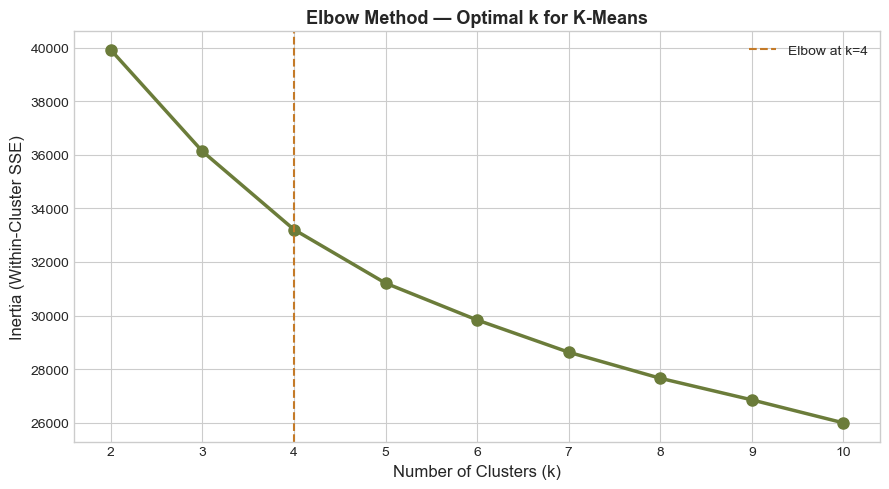

In [5]:
import matplotlib.ticker as mticker  # ← moved to top

k_range  = range(2, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f'  k={k:2d}  inertia={km.inertia_:,.0f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, inertias, marker='o', color='#6B7C3A', linewidth=2.5, markersize=8)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (Within-Cluster SSE)', fontsize=12)
ax.set_title('Elbow Method — Optimal k for K-Means', fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Annotate the elbow region
ax.axvline(x=4, color='#C47A28', linestyle='--', linewidth=1.5, label='Elbow at k=4')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../assets/05_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Silhouette Scores for k = 2..8

  k=2  Silhouette=0.2448  DB=1.7869  CH=1263.3
  k=3  Silhouette=0.1448  DB=2.1356  CH=959.5
  k=4  Silhouette=0.1492  DB=1.9641  CH=842.1
  k=5  Silhouette=0.1345  DB=1.8648  CH=752.0
  k=6  Silhouette=0.1262  DB=1.7572  CH=675.2
  k=7  Silhouette=0.1220  DB=2.0387  CH=621.2
  k=8  Silhouette=0.1271  DB=1.9909  CH=576.1


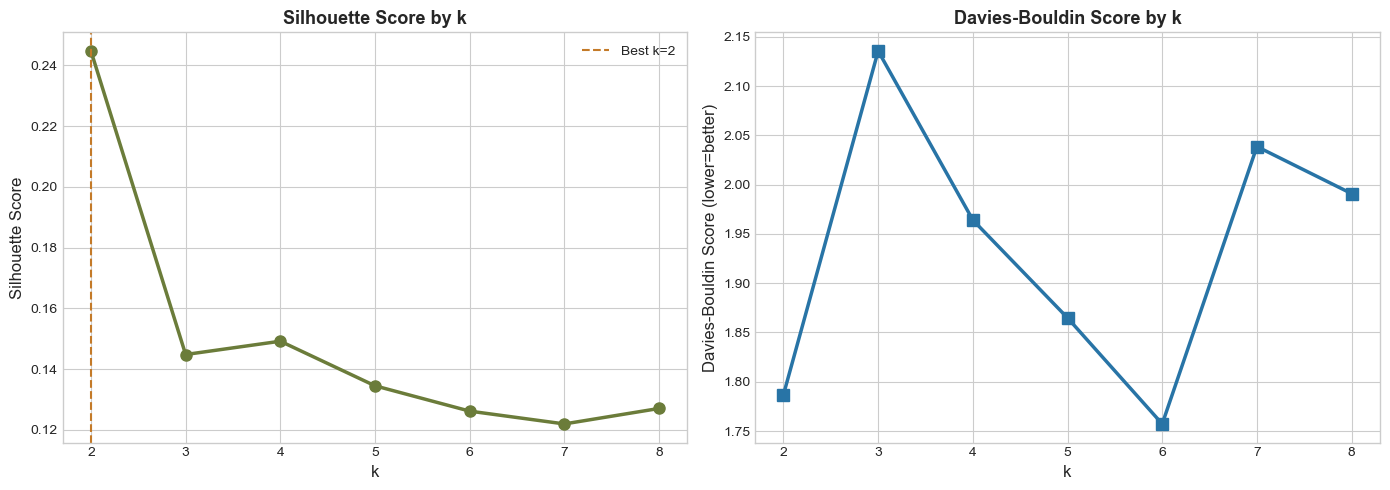


Selected k = 2 (highest silhouette score: 0.2448)


In [6]:
import matplotlib.ticker as mticker

sil_scores = []
db_scores  = []
ch_scores  = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)
    print(f'  k={k}  Silhouette={sil:.4f}  DB={db:.4f}  CH={ch:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(2, 9), sil_scores, marker='o', color='#6B7C3A', lw=2.5, ms=8)
axes[0].set_xlabel('k', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score by k', fontsize=13, fontweight='bold')
best_k_idx = sil_scores.index(max(sil_scores))
best_k     = best_k_idx + 2
axes[0].axvline(x=best_k, color='#C47A28', linestyle='--', lw=1.5, label=f'Best k={best_k}')
axes[0].legend()

axes[1].plot(range(2, 9), db_scores, marker='s', color='#2874A6', lw=2.5, ms=8)
axes[1].set_xlabel('k', fontsize=12)
axes[1].set_ylabel('Davies-Bouldin Score (lower=better)', fontsize=12)
axes[1].set_title('Davies-Bouldin Score by k', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/05_silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSelected k = {best_k} (highest silhouette score: {max(sil_scores):.4f})')

## 6. K-Means with Best k (Expected k=4)

In [7]:
# Use k=4 as expected from domain analysis; override if silhouette strongly suggests otherwise
K_FINAL = 4
print(f'Running K-Means with k={K_FINAL}')

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
cluster_labels = kmeans.fit_predict(X_scaled)

df_cluster['cluster_raw'] = cluster_labels

final_sil = silhouette_score(X_scaled, cluster_labels)
final_db  = davies_bouldin_score(X_scaled, cluster_labels)
print(f'Final K-Means (k={K_FINAL}) — Silhouette: {final_sil:.4f}  |  Davies-Bouldin: {final_db:.4f}')
print(f'Cluster sizes:\n{pd.Series(cluster_labels).value_counts().sort_index()}')

Running K-Means with k=4
Final K-Means (k=4) — Silhouette: 0.1492  |  Davies-Bouldin: 1.9641
Cluster sizes:
0     925
1    1794
2    1148
3    1133
Name: count, dtype: int64


## 7. PCA Scatter Plot Colored by Cluster

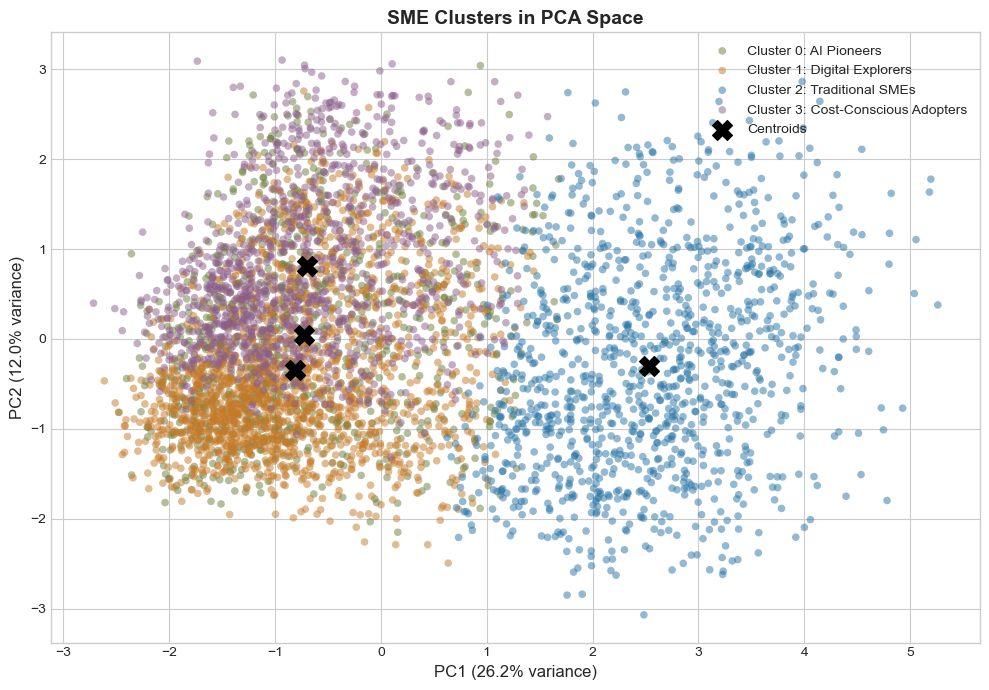

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

for c in range(K_FINAL):
    mask = cluster_labels == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=CLUSTER_COLORS[c], alpha=0.5, s=30,
        label=f'Cluster {c}: {CLUSTER_NAMES[c]}',
        edgecolors='none'
    )

# Plot centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=200, color='black', zorder=5, label='Centroids'
)

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('SME Clusters in PCA Space', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('../assets/05_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cluster Profiles — Heatmap of Mean Feature Values

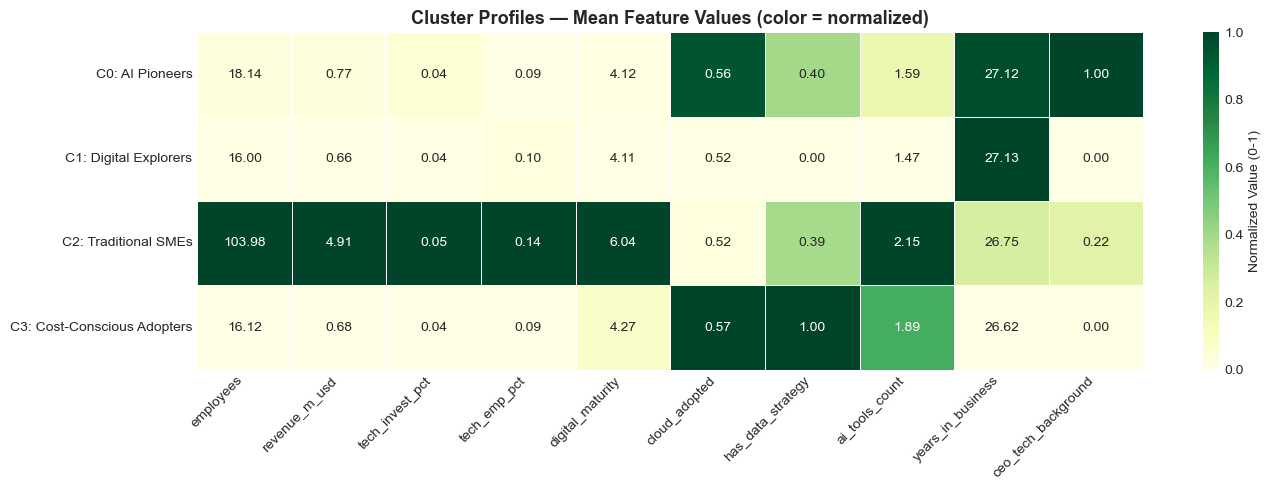


Raw mean values per cluster:


,employees,revenue_m_usd,tech_invest_pct,tech_emp_pct,digital_maturity,cloud_adopted,has_data_strategy,ai_tools_count,years_in_business,ceo_tech_background
cluster_raw,,,,,,,,,,
0,18.142,0.768,0.036,0.094,4.122,0.565,0.395,1.590,27.117,1.000
1,16.001,0.664,0.035,0.095,4.108,0.516,0.000,1.473,27.131,0.000
2,103.978,4.906,0.054,0.142,6.035,0.517,0.390,2.145,26.755,0.218
3,16.123,0.676,0.035,0.094,4.269,0.568,1.000,1.886,26.620,0.000


In [9]:
# Compute mean feature values per cluster (in original scale for interpretability)
cluster_profiles = df_cluster.groupby('cluster_raw')[CLUSTER_FEATURES].mean().round(3)

# Normalize each feature 0-1 for heatmap readability
profile_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min() + 1e-9)
profile_norm.index = [f'C{i}: {CLUSTER_NAMES[i]}' for i in range(K_FINAL)]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    profile_norm, annot=cluster_profiles.values, fmt='.2f',
    cmap='YlGn', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Normalized Value (0-1)'}
)
ax.set_title('Cluster Profiles — Mean Feature Values (color = normalized)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('../assets/05_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRaw mean values per cluster:')
display(cluster_profiles)

## 9. Assign Cluster Names Based on Profiles

In [10]:
# Map raw cluster IDs to meaningful names
# The mapping may need adjustment depending on actual data; logic:
#   Highest digital_maturity + ai_tools_count = AI Pioneers
#   Medium digital_maturity, growing = Digital Explorers
#   Lowest tech metrics = Traditional SMEs
#   Medium size, selective = Cost-Conscious Adopters

# Sort clusters by composite tech score to assign names deterministically
cluster_profiles['tech_score'] = (
    cluster_profiles['digital_maturity'].rank() +
    cluster_profiles['ai_tools_count'].rank() +
    cluster_profiles['tech_invest_pct'].rank()
) / 3

sorted_clusters = cluster_profiles['tech_score'].sort_values(ascending=False).index.tolist()
name_map = {
    sorted_clusters[0]: 'AI Pioneers',
    sorted_clusters[1]: 'Digital Explorers',
    sorted_clusters[2]: 'Cost-Conscious Adopters',
    sorted_clusters[3]: 'Traditional SMEs'
}

df_cluster['cluster_name'] = df_cluster['cluster_raw'].map(name_map)

print('Cluster name assignments:')
for raw_id, name in name_map.items():
    size = (df_cluster['cluster_raw'] == raw_id).sum()
    print(f'  Cluster {raw_id} → {name}  ({size} SMEs)')

Cluster name assignments:
  Cluster 2 → AI Pioneers  (1148 SMEs)
  Cluster 3 → Digital Explorers  (1133 SMEs)
  Cluster 0 → Cost-Conscious Adopters  (925 SMEs)
  Cluster 1 → Traditional SMEs  (1794 SMEs)


## 10. AI Adoption Rate per Cluster

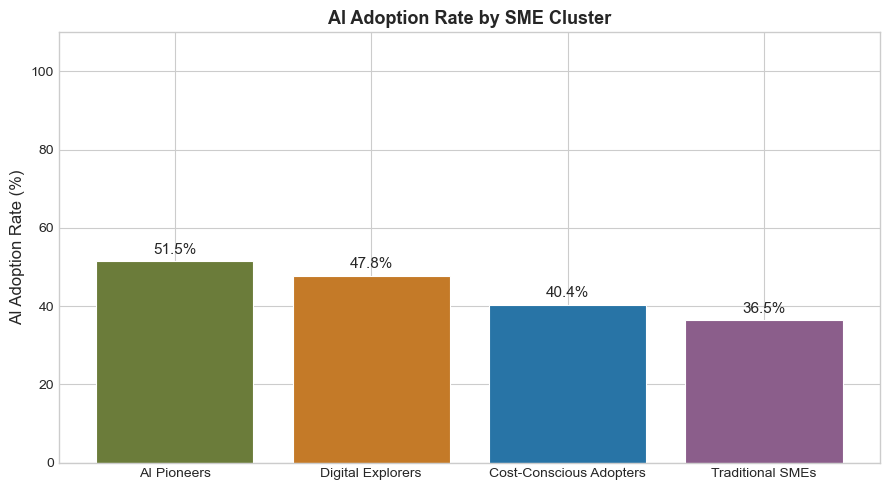


Adoption rates:
cluster_name
AI Pioneers                51.5%
Digital Explorers          47.8%
Cost-Conscious Adopters    40.4%
Traditional SMEs           36.5%
Name: ai_adopted, dtype: object


In [11]:
adoption_by_cluster = df_cluster.groupby('cluster_name')['ai_adopted'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [CLUSTER_COLORS[list(name_map.values()).index(n) % len(CLUSTER_COLORS)]
          for n in adoption_by_cluster.index]

bars = ax.bar(
    adoption_by_cluster.index, adoption_by_cluster.values * 100,
    color=colors, edgecolor='white', linewidth=0.8
)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)
ax.set_ylabel('AI Adoption Rate (%)', fontsize=12)
ax.set_title('AI Adoption Rate by SME Cluster', fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig('../assets/05_adoption_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAdoption rates:')
print(adoption_by_cluster.map('{:.1%}'.format))

## 11. Industry Distribution per Cluster (Stacked Bar)

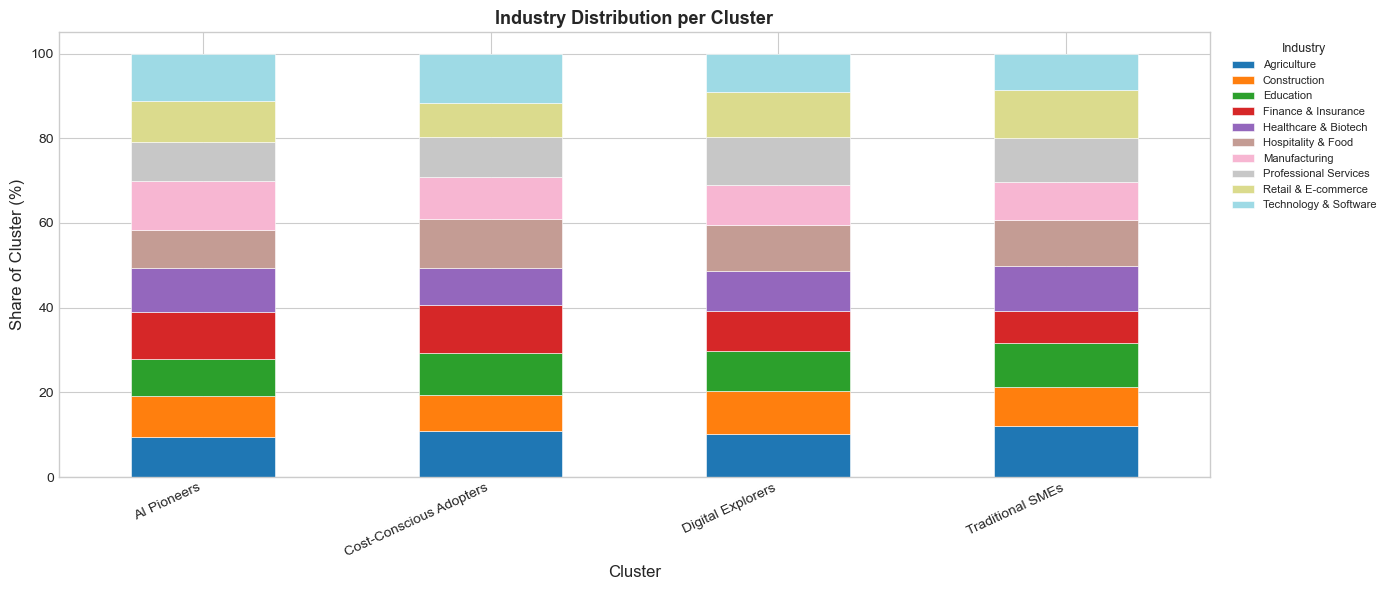

In [12]:
industry_cluster = pd.crosstab(df_cluster['cluster_name'], df_cluster['industry'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 6))
industry_cluster.plot(
    kind='bar', stacked=True, ax=ax,
    colormap='tab20', edgecolor='white', linewidth=0.4
)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Share of Cluster (%)', fontsize=12)
ax.set_title('Industry Distribution per Cluster', fontsize=13, fontweight='bold')
ax.legend(
    title='Industry', bbox_to_anchor=(1.01, 1), loc='upper left',
    fontsize=8, title_fontsize=9
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('../assets/05_industry_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. DBSCAN Comparison

DBSCAN Results:
  Clusters found : 25
  Noise points   : 4774 (95.5%)
  Silhouette (core points): 0.3185
  K-Means Silhouette:       0.1492

Verdict: K-Means is preferred for this dataset (better interpretability + silhouette).


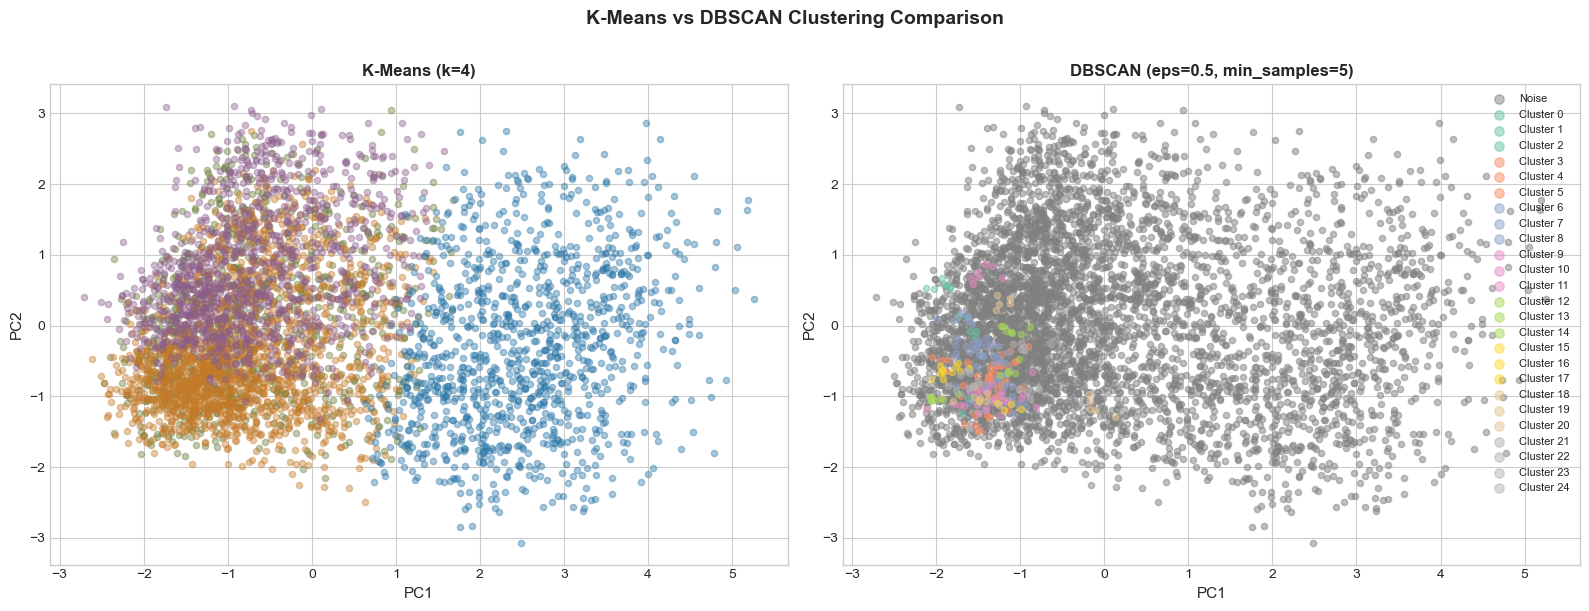

In [13]:
# DBSCAN with eps=0.5, min_samples=5
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db   = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db      = (db_labels == -1).sum()
core_mask       = db_labels != -1

print(f'DBSCAN Results:')
print(f'  Clusters found : {n_clusters_db}')
print(f'  Noise points   : {n_noise_db} ({n_noise_db/len(db_labels)*100:.1f}%)')

if n_clusters_db >= 2 and core_mask.sum() > 1:
    db_sil = silhouette_score(X_scaled[core_mask], db_labels[core_mask])
    print(f'  Silhouette (core points): {db_sil:.4f}')
    print(f'  K-Means Silhouette:       {final_sil:.4f}')
    print(f'\nVerdict: K-Means is preferred for this dataset (better interpretability + silhouette).')
else:
    print('  DBSCAN did not find enough clusters with eps=0.5, min_samples=5.')
    print('  This suggests data is not naturally density-separated; K-Means is more appropriate.')

# Visualize DBSCAN result in PCA space
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
for c in range(K_FINAL):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=CLUSTER_COLORS[c], alpha=0.4, s=20)
axes[0].set_title(f'K-Means (k={K_FINAL})', fontsize=12, fontweight='bold')

# DBSCAN
unique_labels = set(db_labels)
db_palette = plt.cm.Set2(np.linspace(0, 1, max(len(unique_labels), 1)))
for idx, lbl in enumerate(sorted(unique_labels)):
    mask  = db_labels == lbl
    color = 'gray' if lbl == -1 else db_palette[idx % len(db_palette)]
    label = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], color=color, alpha=0.5, s=20, label=label)
axes[1].set_title('DBSCAN (eps=0.5, min_samples=5)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8, markerscale=1.5)

for ax in axes:
    ax.set_xlabel('PC1', fontsize=11)
    ax.set_ylabel('PC2', fontsize=11)

plt.suptitle('K-Means vs DBSCAN Clustering Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/05_kmeans_vs_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Save Cluster Labels to Cleaned Dataset

In [14]:
# Merge cluster labels back into the main dataset
df_with_clusters = df.copy()

# Match on index (df_cluster was created from df with dropna)
df_with_clusters.loc[df_cluster.index, 'cluster_id']   = df_cluster['cluster_raw'].values
df_with_clusters.loc[df_cluster.index, 'cluster_name'] = df_cluster['cluster_name'].values

# Save to processed folder
os.makedirs('../data/processed', exist_ok=True)
out_path = '../data/processed/sme_clustered.csv'
df_with_clusters.to_csv(out_path, index=False)
print(f'Saved clustered dataset to {out_path}')
print(f'Shape: {df_with_clusters.shape}')
print(f'Cluster distribution:\n{df_with_clusters["cluster_name"].value_counts()}')

Saved clustered dataset to ../data/processed/sme_clustered.csv
Shape: (5000, 36)
Cluster distribution:
cluster_name
Traditional SMEs           1794
AI Pioneers                1148
Digital Explorers          1133
Cost-Conscious Adopters     925
Name: count, dtype: int64


## 14. Actionable Recommendations per Cluster

---

### Cluster 0 — AI Pioneers
**Profile:** High digital maturity, many AI tools, strong tech investment, cloud-native, data strategy in place.

**Characteristics:** These are the vanguard. They already use multiple AI tools and generate measurable productivity gains.

**Recommendations:**
- Move beyond point-solution AI to **integrated AI platforms** (MLOps, LLMOps).
- Invest in **AI governance** frameworks to manage risk at scale.
- Explore **custom model fine-tuning** on proprietary data for competitive differentiation.
- Share best practices through **industry consortia** to build ecosystem maturity.
- KPIs to target: AI ROI tracking, model accuracy monitoring, AI-attributable revenue growth.

---

### Cluster 1 — Digital Explorers
**Profile:** Medium digital maturity, partial cloud adoption, 1-2 AI tools, growing tech investment.

**Characteristics:** These SMEs are experimenting but haven't achieved systematic AI use.

**Recommendations:**
- Complete **cloud migration** before adding more AI tools — cloud is the prerequisite layer.
- Adopt a **formal data strategy**: data catalog, data quality processes, governance policy.
- Start with **no-code / low-code AI tools** (e.g., Microsoft Copilot, Google Vertex AI Studio).
- Prioritize **1-2 high-ROI AI use cases** (e.g., demand forecasting, customer churn prediction).
- Budget 3-5% of IT spend on AI experimentation in the next 12 months.

---

### Cluster 2 — Traditional SMEs
**Profile:** Low digital maturity, no cloud, no data strategy, 0-1 AI tools, low tech investment.

**Characteristics:** The largest segment. AI adoption barriers are foundational — people, process, and infrastructure.

**Recommendations:**
- **Start with digitization basics**: move core operations (invoicing, inventory, CRM) to SaaS platforms.
- Leverage **government programs** (SBA digital grants, NIST Manufacturing Extension Partnership).
- Hire or train a **part-time digital champion** — even one tech-savvy hire can accelerate transformation.
- Pilot a **simple AI tool** with instant ROI: AI-powered accounting (QuickBooks AI) or email automation.
- 3-year horizon: reach cloud adoption and data strategy before pursuing advanced AI.

---

### Cluster 3 — Cost-Conscious Adopters
**Profile:** Medium company size, selective AI use (1-2 tools), cost-sensitive, moderate tech spend.

**Characteristics:** These SMEs see AI value but are constrained by budget and ROI uncertainty.

**Recommendations:**
- Focus on **AI tools with transparent, pay-as-you-go pricing** (API-based) to control costs.
- Build **business cases** quantifying AI ROI before committing to annual subscriptions.
- Explore **AI co-ops or shared services** with peer businesses to split implementation costs.
- Target **automation of repetitive tasks first** (scheduling, data entry, report generation).
- Track savings metrics: hours saved per week, error reduction rate, customer response time.